# Customer Churn

## Downloading dataset


In [2]:
import pandas as pd
import numpy as np
import os

In [3]:
import kagglehub


# Download latest version
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Path to dataset files:", path)

/Users/yassinmarwan/anaconda3/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /Users/yassinmarwan/.cache/kagglehub/datasets/blastchar/telco-customer-churn/versions/1


In [4]:
file_path = os.path.join(path, "WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [5]:
df = pd.read_csv(file_path)

In [9]:
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Analysis

In [8]:

print("1. SHAPE:\n", df.shape)
print("\n2. COLUMNS:\n", df.columns.tolist())
print("\n3. DTYPES:\n", df.dtypes)
print("\n4. MISSING VALUES:\n", df.isnull().sum())
print("\n5. DUPLICATES:\n", df.duplicated().sum())
print("\n6. DESCRIBE:\n", df.describe(include="all"))


1. SHAPE:
 (7043, 21)

2. COLUMNS:
 ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

3. DTYPES:
 customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

4. MISSING VALUES:
 cust

In [9]:
print(
    "\n7. CATEGORICAL UNIQUE VALUES:\n",
    {col: df[col].nunique() for col in df.select_dtypes(include="object")},
)
print(
    "\n8. GENDER COUNTS:\n",
    df["gender"].value_counts() if "gender" in df else "N/A",
)
print(
    "\n9. CONTRACT COUNTS:\n",
    df["Contract"].value_counts() if "Contract" in df else "N/A",
)
print(
    "\n10. PAYMENT METHOD COUNTS:\n",
    df["PaymentMethod"].value_counts() if "PaymentMethod" in df else "N/A",
)
print(
    "\n11. CHURN COUNTS:\n",
    df["Churn"].value_counts() if "Churn" in df else "N/A",
)


7. CATEGORICAL UNIQUE VALUES:
 {'customerID': 7043, 'gender': 2, 'Partner': 2, 'Dependents': 2, 'PhoneService': 2, 'MultipleLines': 3, 'InternetService': 3, 'OnlineSecurity': 3, 'OnlineBackup': 3, 'DeviceProtection': 3, 'TechSupport': 3, 'StreamingTV': 3, 'StreamingMovies': 3, 'Contract': 3, 'PaperlessBilling': 2, 'PaymentMethod': 4, 'TotalCharges': 6531, 'Churn': 2}

8. GENDER COUNTS:
 gender
Male      3555
Female    3488
Name: count, dtype: int64

9. CONTRACT COUNTS:
 Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

10. PAYMENT METHOD COUNTS:
 PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

11. CHURN COUNTS:
 Churn
No     5174
Yes    1869
Name: count, dtype: int64


## Comments on analysis

#### First Comment : We have 21 feature 
#### Second Comment : We have no duplicate customers
#### Third comment : The features contains both Numerical and catagorical data
#### Fourth Comment : We have no missing data






## Further Analysis

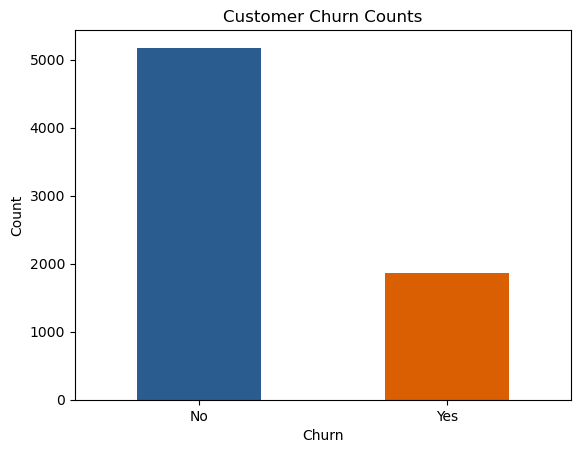

In [10]:
import matplotlib.pyplot as plt

df["Churn"].value_counts().plot(
    kind="bar",
    color=["#2b5c8f", "#d95f02"],
    rot=0,
    title="Customer Churn Counts",
)
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

In [11]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

print(contract_churn)

Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


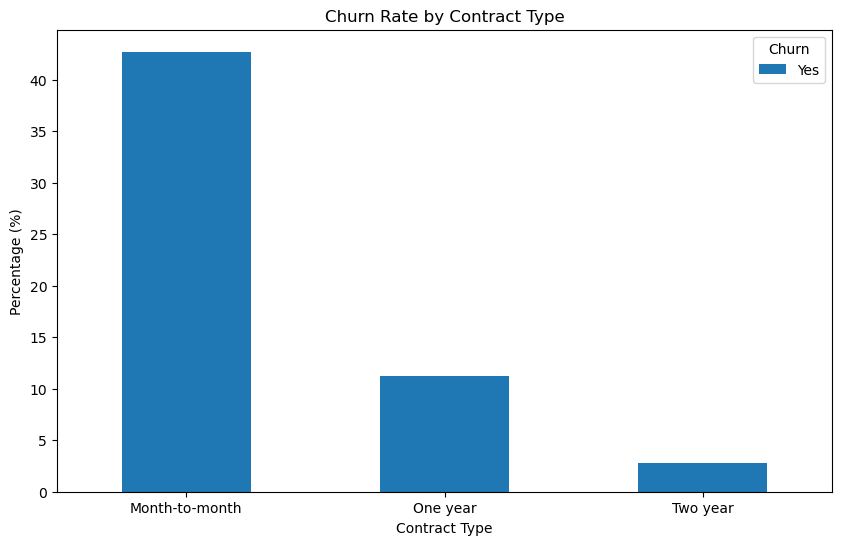

In [12]:
import matplotlib.pyplot as plt

contract_churn['Yes'].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.xlabel("Contract Type")
plt.ylabel("Percentage (%)")
plt.title("Churn Rate by Contract Type")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.show()

In [13]:
partner_churn = pd.crosstab(
    df["Partner"],
    df["Churn"],
    normalize="index"
) * 100

print(partner_churn)



Churn           No        Yes
Partner                      
No       67.042021  32.957979
Yes      80.335097  19.664903


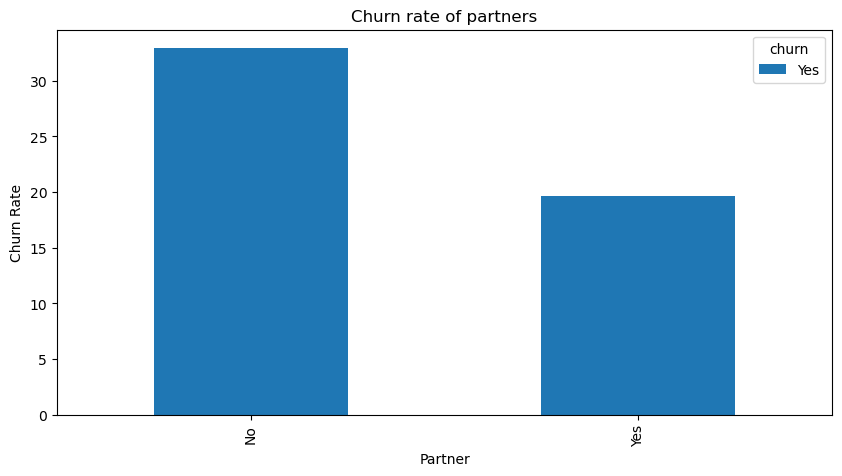

In [14]:
partner_churn['Yes'].plot(
    kind= "bar",
    figsize=(10,5))
plt.xlabel("Partner")
plt.ylabel("Churn Rate")
plt.title("Churn rate of partners")
plt.legend(title="churn")
plt.show()

In [15]:
SeniorCitizen_churn = pd.crosstab(
    df["SeniorCitizen"],
    df["Churn"],
    normalize="index"
) * 100

print(SeniorCitizen_churn)



Churn                 No        Yes
SeniorCitizen                      
0              76.393832  23.606168
1              58.318739  41.681261


In [16]:
Gender_churn = pd.crosstab(
    df["gender"],
    df["Churn"],
    normalize="index"
) * 100

print(Gender_churn)



Churn          No        Yes
gender                      
Female  73.079128  26.920872
Male    73.839662  26.160338


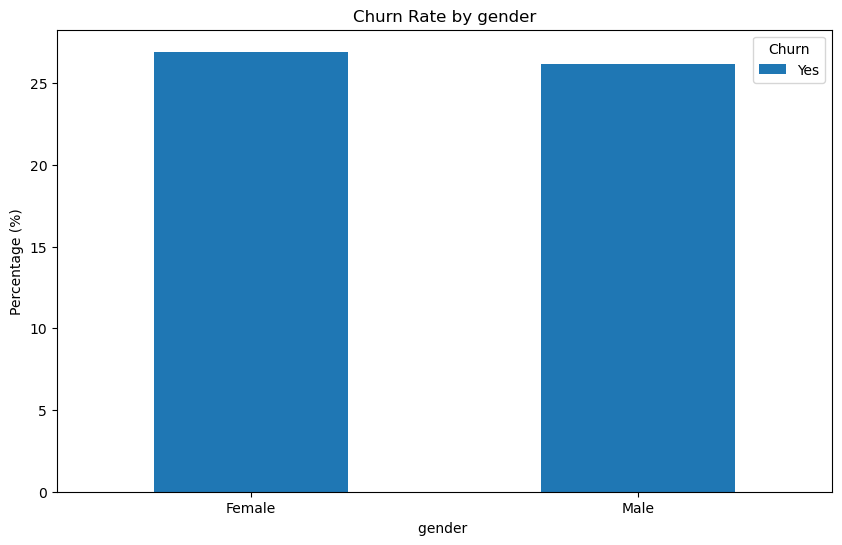

In [17]:

Gender_churn['Yes'].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.xlabel("gender ")
plt.ylabel("Percentage (%)")
plt.title("Churn Rate by gender")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.show()

In [18]:
dep_churn = pd.crosstab(
    df["Dependents"],
    df["Churn"],
    normalize="index"
) * 100

print(dep_churn)



Churn              No        Yes
Dependents                      
No          68.720860  31.279140
Yes         84.549763  15.450237


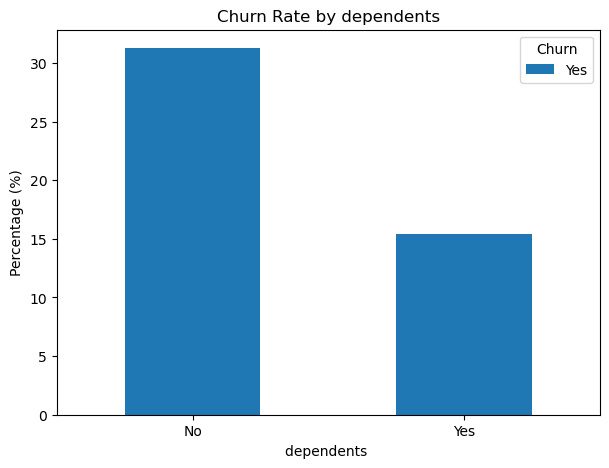

In [19]:

dep_churn['Yes'].plot(
    kind="bar",
    figsize=(7, 5)
)

plt.xlabel("dependents ")
plt.ylabel("Percentage (%)")
plt.title("Churn Rate by dependents")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.show()

In [20]:
bins = list(range(0, 73, 12))   # 0,12,24,...,72


df["Tenure_Group"] = pd.cut(
    df["tenure"],
    bins=bins,
    right=False
)

In [21]:
churn_rate = (
    df.groupby("Tenure_Group")["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .reset_index(name="Churn Rate (%)")
)

print(churn_rate)



  Tenure_Group  Churn Rate (%)
0      [0, 12)       48.284195
1     [12, 24)       29.512894
2     [24, 36)       22.031963
3     [36, 48)       19.518717
4     [48, 60)       15.000000
5     [60, 72)        8.296164


/var/folders/gt/6f_54hcx4_l7y2jy_51ft6f40000gn/T/ipykernel_4893/3446557744.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Tenure_Group")["Churn"]


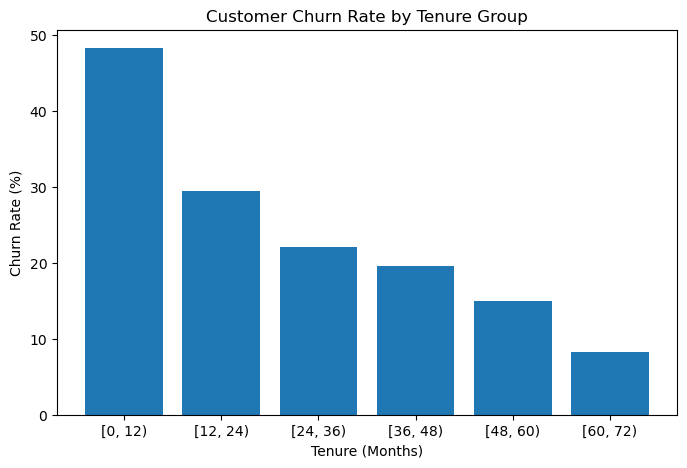

In [22]:
plt.figure(figsize=(8,5))

plt.bar(
    churn_rate["Tenure_Group"].astype(str),
    churn_rate["Churn Rate (%)"]
)

plt.title("Customer Churn Rate by Tenure Group")
plt.xlabel("Tenure (Months)")
plt.ylabel("Churn Rate (%)")

plt.show()

In [23]:
df.head(20)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Tenure_Group
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,"[0, 12)"
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.5,No,"[24, 36)"
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,"[0, 12)"
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,"[36, 48)"
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,"[0, 12)"
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,"[0, 12)"
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No,"[12, 24)"
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No,"[0, 12)"
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,"[24, 36)"
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No,"[60, 72)"


In [24]:
kebeer=df['MonthlyCharges'].max()
kebeer

118.75

In [25]:
soghayar=df['MonthlyCharges'].min()
soghayar

18.25

In [26]:
price_ranges = np.arange(18.25, 118.75,20.0) 


df["Price_Groups"] = pd.cut(
    df["MonthlyCharges"],
    bins=price_ranges,
    right=False
)

In [27]:
churn_rate2 = (
    df.groupby("Price_Groups")["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .reset_index(name="Churn Rate (%)")
)

print(churn_rate2)

      Price_Groups  Churn Rate (%)
0   [18.25, 38.25)       11.414254
1   [38.25, 58.25)       27.181545
2   [58.25, 78.25)       29.120473
3   [78.25, 98.25)       36.663008
4  [98.25, 118.25)       30.841121


/var/folders/gt/6f_54hcx4_l7y2jy_51ft6f40000gn/T/ipykernel_4893/560884297.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Price_Groups")["Churn"]


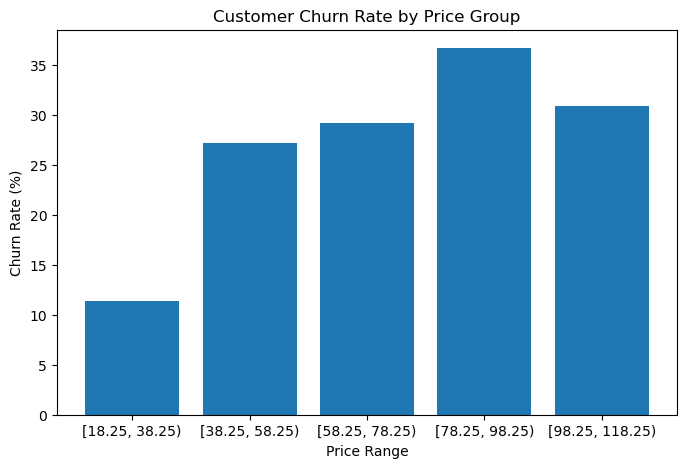

In [28]:
plt.figure(figsize=(8,5))

plt.bar(
    churn_rate2["Price_Groups"].astype(str),
    churn_rate2["Churn Rate (%)"]
)

plt.title("Customer Churn Rate by Price Group")
plt.xlabel("Price Range")
plt.ylabel("Churn Rate (%)")

plt.show()

In [29]:

# Ensure TotalCharges is numeric (handles missing/blank string values)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Calculate Mean and Median grouped by Churn
spending_stats = df.groupby('Churn')['TotalCharges'].agg(['mean', 'median', 'count', 'std'])
print(spending_stats)

              mean   median  count          std
Churn                                          
No     2555.344141  1683.60   5163  2329.456984
Yes    1531.796094   703.55   1869  1890.822994


In [30]:
OnlineSec_churn = pd.crosstab(
    df["OnlineSecurity"],
    df["Churn"],
    normalize="index"
) * 100

print(OnlineSec_churn)

#repitive to cell 40


Churn                       No        Yes
OnlineSecurity                           
No                   58.233276  41.766724
No internet service  92.595020   7.404980
Yes                  85.388806  14.611194


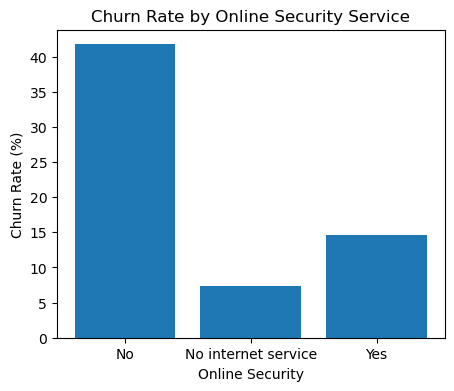

In [31]:
plt.figure(figsize=(5, 4))

plt.bar(
    OnlineSec_churn.index,
    OnlineSec_churn["Yes"]
)

plt.title("Churn Rate by Online Security Service")
plt.xlabel("Online Security")
plt.ylabel("Churn Rate (%)")

plt.show()
#repitive to cell 40


In [32]:
OnlineBackup_churn = pd.crosstab(
    df["OnlineBackup"],
    df["Churn"],
    normalize="index"
) * 100

print(OnlineBackup_churn)

#repitive to cell 40



Churn                       No        Yes
OnlineBackup                             
No                   60.071244  39.928756
No internet service  92.595020   7.404980
Yes                  78.468506  21.531494


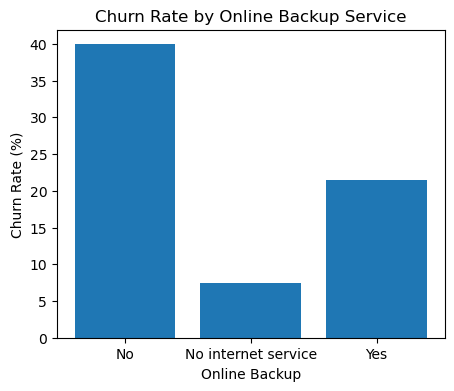

In [33]:
plt.figure(figsize=(5, 4))

plt.bar(
    OnlineBackup_churn.index,
    OnlineBackup_churn["Yes"]
)

plt.title("Churn Rate by Online Backup Service")
plt.xlabel("Online Backup")
plt.ylabel("Churn Rate (%)")

plt.show()
#repitive to cell 40


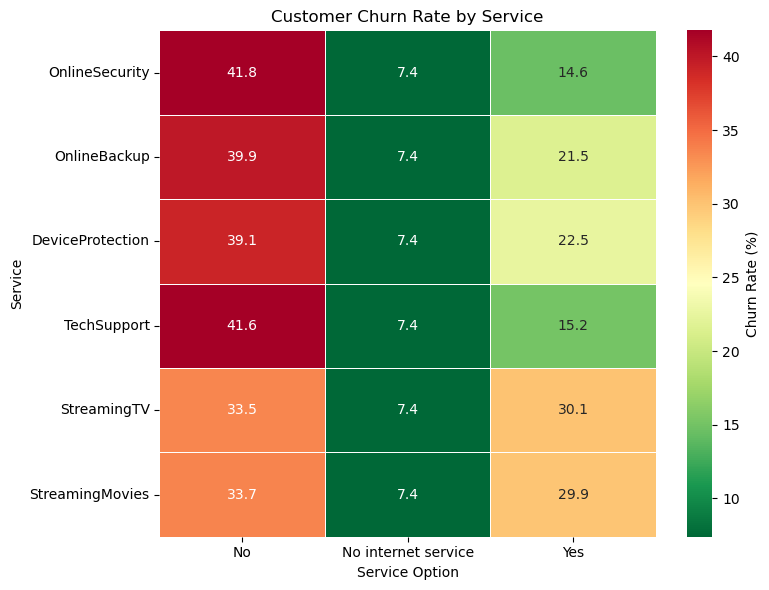

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

services = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
]

# Build heatmap dataframe
heatmap_data = pd.DataFrame()

for service in services:
    churn_rate = (
        pd.crosstab(df[service], df["Churn"], normalize="index")["Yes"] * 100
    )
    heatmap_data[service] = churn_rate

# Transpose so services are rows
heatmap_data = heatmap_data.T

# Plot
plt.figure(figsize=(8, 6))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn_r",
    linewidths=0.5,
    cbar_kws={"label": "Churn Rate (%)"}
)

plt.title("Customer Churn Rate by Service")
plt.xlabel("Service Option")
plt.ylabel("Service")

plt.tight_layout()
plt.show()

In [35]:
PhoneService_churn = pd.crosstab(
    df["PhoneService"],
    df["Churn"],
    normalize="index"
) * 100

print(PhoneService_churn)



Churn                No        Yes
PhoneService                      
No            75.073314  24.926686
Yes           73.290363  26.709637


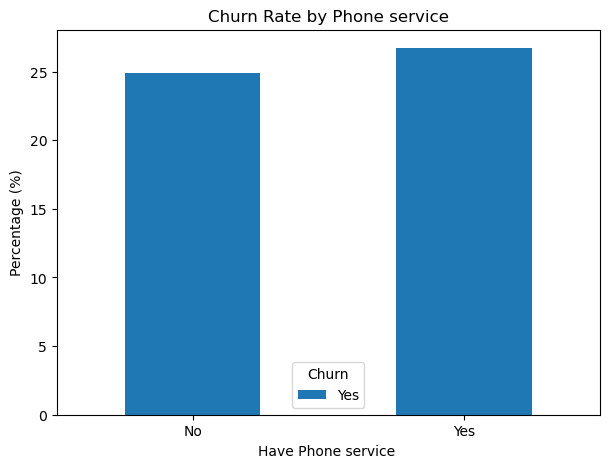

In [36]:

PhoneService_churn['Yes'].plot(
    kind="bar",
    figsize=(7, 5)
)

plt.xlabel("Have Phone service ")
plt.ylabel("Percentage (%)")
plt.title("Churn Rate by Phone service")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.show()

In [37]:
MultipleLines_churn = pd.crosstab(
    df["MultipleLines"],
    df["Churn"],
    normalize="index"
) * 100

print(MultipleLines_churn)



Churn                    No        Yes
MultipleLines                         
No                74.955752  25.044248
No phone service  75.073314  24.926686
Yes               71.390104  28.609896


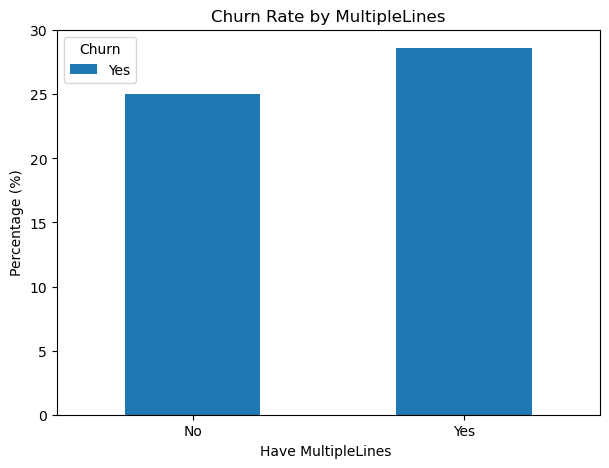

In [38]:

MultipleLines_churn['Yes'].drop('No phone service').plot(
    kind="bar",
    figsize=(7, 5)
)

plt.xlabel("Have MultipleLines ")
plt.ylabel("Percentage (%)")
plt.title("Churn Rate by MultipleLines")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.show()

In [39]:
InternetService_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

print(InternetService_churn)


Churn                   No        Yes
InternetService                      
DSL              81.040892  18.959108
Fiber optic      58.107235  41.892765
No               92.595020   7.404980


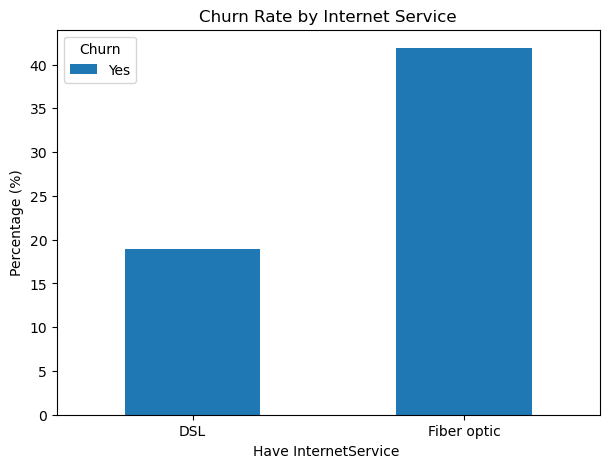

In [40]:

InternetService_churn['Yes'].drop('No').plot(
    kind="bar",
    figsize=(7, 5)
)

plt.xlabel("Have InternetService ")
plt.ylabel("Percentage (%)")
plt.title("Churn Rate by Internet Service")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.show()

In [41]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Tenure_Group,Price_Groups
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,"[0, 12)","[18.25, 38.25)"
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,One year,No,Mailed check,56.95,1889.50,No,"[24, 36)","[38.25, 58.25)"
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,"[0, 12)","[38.25, 58.25)"
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,"[36, 48)","[38.25, 58.25)"
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,"[0, 12)","[58.25, 78.25)"


In [42]:
PaymentMethod_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

print(PaymentMethod_churn)


Churn                             No        Yes
PaymentMethod                                  
Bank transfer (automatic)  83.290155  16.709845
Credit card (automatic)    84.756899  15.243101
Electronic check           54.714588  45.285412
Mailed check               80.893300  19.106700


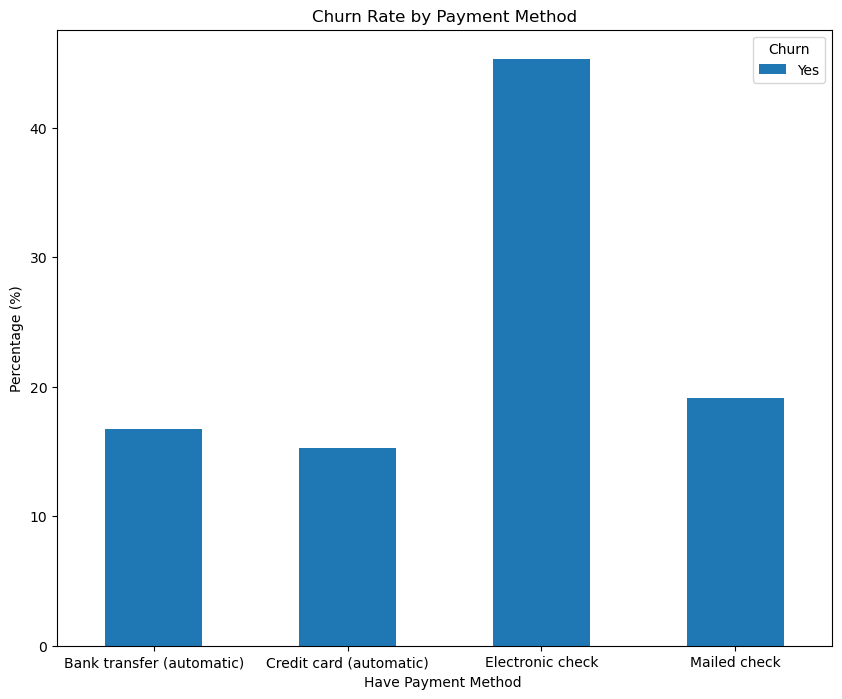

In [43]:

PaymentMethod_churn['Yes'].plot(
    kind="bar",
    figsize=(10, 8)
)

plt.xlabel("Have Payment Method ")
plt.ylabel("Percentage (%)")
plt.title("Churn Rate by Payment Method")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.show()

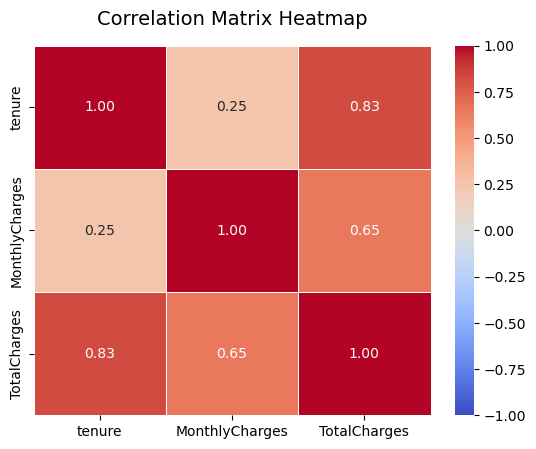

In [44]:
import seaborn as sns

corr_matrix = df[['tenure','MonthlyCharges', 'TotalCharges']].corr(method='pearson')
sns.heatmap(
    corr_matrix, 
    annot=True,          # Show the correlation numbers
    cmap='coolwarm',     # Red for positive, Blue for negative correlation
    fmt=".2f",           # Round to 2 decimal places
    vmin=-1, vmax=1,     # Anchors the colorbar scale from -1 to 1
          # Conceal mirror-image values for cleaner look
    linewidths=0.5       # Add thin lines between boxes
)

plt.title('Correlation Matrix Heatmap', fontsize=14, pad=15)
plt.show()

In [45]:
df.groupby("Churn")["MonthlyCharges"].agg(["mean", "median", "count"]).round(2)

,mean,median,count
Churn,,,
No,61.27,64.43,5174
Yes,74.44,79.65,1869


## business insight 

Percentage of Churning : 26.53% 
Highest-Risk Contract is Month to month Contract by : 42.71%  
Highest-risk tenure group [0-12] Months by : 48.284195%  
Highest-risk internet service is fiber optic by: 41.892765%  
Average monthly charge of churned customers: $74.44

Average monthly charge of retained customers: $61.27  


Most concerning customer profile: **Month to month** , **single (with no partner)**, **[0-12]** month tenure , with **no dependents** , Customers with **high monthly payments** , customers with **no (Internet security, no backups, no device protection, no tech support )** with **fiber optic** and paying with **electronic check**

# Preprocessing

In [23]:
def preprocessing(df):
    ml_df = df.copy()
    X = ml_df.drop(columns=['Churn'])
    Y = ml_df['Churn'].map({"No": 0, "Yes": 1})  
    X = X.drop("customerID", axis=1)
    X['TotalCharges'] = pd.to_numeric(X['TotalCharges'], errors='coerce')
    X['TotalCharges'] = X['TotalCharges'].fillna(X['TotalCharges'].median())
    X["gender"] = X["gender"].map({"Female":0, "Male":1})
    X["Partner"] = X["Partner"].map({"Yes":0, "No":1})
    X["Dependents"] = X["Dependents"].map({"Yes":0, "No":1})
    X["PhoneService"] = X["PhoneService"].map({"Yes":0, "No":1})
    X["PaperlessBilling"] = X["PaperlessBilling"].map({"Yes":0, "No":1})
    X = pd.get_dummies(X, drop_first=True)
    bool_cols = X.select_dtypes(include=['bool']).columns
    X[bool_cols] = X[bool_cols].astype(int)
    return X, Y

In [47]:
ml_df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Tenure_Group,Price_Groups
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,"[0, 12)","[18.25, 38.25)"
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,One year,No,Mailed check,56.95,1889.50,No,"[24, 36)","[38.25, 58.25)"
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,"[0, 12)","[38.25, 58.25)"
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,"[36, 48)","[38.25, 58.25)"
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,"[0, 12)","[58.25, 78.25)"


In [48]:
ml_df.drop(columns=['Tenure_Group','Price_Groups','Churn'])

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60


In [49]:
X = ml_df.drop(columns=['Tenure_Group','Price_Groups','Churn'])
Y = ml_df['Churn']

In [50]:
X

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60


In [46]:
# Create a working copy for preprocessing
ml_df = df.copy()

In [51]:
Y

0        No
1        No
2       Yes
3        No
4       Yes
       ... 
7038     No
7039     No
7040     No
7041    Yes
7042     No
Name: Churn, Length: 7043, dtype: object

In [52]:
Y = Y.map({'Yes':1 , 'No':0})

In [53]:
Y

0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: Churn, Length: 7043, dtype: int64

In [54]:
X = X.drop("customerID", axis=1)

In [55]:
X.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
dtype: int64

In [56]:
X['TotalCharges'] = pd.to_numeric(X['TotalCharges'], errors='coerce')
X['TotalCharges'] = X['TotalCharges'].fillna(X['TotalCharges'].median())


In [57]:
X

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60


In [58]:
X.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
dtype: int64

In [59]:
X.select_dtypes(include="object").columns

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

In [60]:
X["gender"] = X["gender"].map({"Female":0, "Male":1})

In [61]:
X

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,0,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,1,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50
2,1,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15
3,1,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,0,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50
7039,0,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90
7040,0,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45
7041,1,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60


In [62]:
X["Partner"] = X["Partner"].map({"Yes":0, "No":1})
X["Dependents"] = X["Dependents"].map({"Yes":0, "No":1})
X["PhoneService"] = X["PhoneService"].map({"Yes":0, "No":1})
X["PaperlessBilling"] = X["PaperlessBilling"].map({"Yes":0, "No":1})

In [63]:
X["Dependents"] = X["Dependents"].map({"Yes":0, "No":1})

In [64]:
X["PhoneService"] = X["PhoneService"].map({"Yes":0, "No":1})

In [65]:
X["PaperlessBilling"] = X["PaperlessBilling"].map({"Yes":0, "No":1})

In [66]:
X

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,0,0,0,1,1,1,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,0,Electronic check,29.85,29.85
1,1,0,1,1,34,0,No,DSL,Yes,No,Yes,No,No,No,One year,1,Mailed check,56.95,1889.50
2,1,0,1,1,2,0,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,0,Mailed check,53.85,108.15
3,1,0,1,1,45,1,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,1,Bank transfer (automatic),42.30,1840.75
4,0,0,1,1,2,0,No,Fiber optic,No,No,No,No,No,No,Month-to-month,0,Electronic check,70.70,151.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,0,0,24,0,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,0,Mailed check,84.80,1990.50
7039,0,0,0,0,72,0,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,0,Credit card (automatic),103.20,7362.90
7040,0,0,0,0,11,1,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,0,Electronic check,29.60,346.45
7041,1,1,0,1,4,0,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,0,Mailed check,74.40,306.60


In [67]:
X.select_dtypes(include="object").columns

Index(['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaymentMethod'],
      dtype='object')

In [68]:
X = pd.get_dummies(X, drop_first=True)

In [69]:
X

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,MultipleLines_No phone service,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,0,1,1,1,0,29.85,29.85,True,...,False,False,False,False,False,False,False,False,True,False
1,1,0,1,1,34,0,1,56.95,1889.50,False,...,False,False,False,False,False,True,False,False,False,True
2,1,0,1,1,2,0,0,53.85,108.15,False,...,False,False,False,False,False,False,False,False,False,True
3,1,0,1,1,45,1,1,42.30,1840.75,True,...,True,False,False,False,False,True,False,False,False,False
4,0,0,1,1,2,0,0,70.70,151.65,False,...,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,0,0,24,0,0,84.80,1990.50,False,...,True,False,True,False,True,True,False,False,False,True
7039,0,0,0,0,72,0,0,103.20,7362.90,False,...,False,False,True,False,True,True,False,True,False,False
7040,0,0,0,0,11,1,0,29.60,346.45,True,...,False,False,False,False,False,False,False,False,True,False
7041,1,1,0,1,4,0,0,74.40,306.60,False,...,False,False,False,False,False,False,False,False,False,True


In [70]:
bool_cols = X.select_dtypes(include=['bool']).columns
X[bool_cols] = X[bool_cols].astype(int)

In [71]:
X

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,MultipleLines_No phone service,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,0,1,1,1,0,29.85,29.85,1,...,0,0,0,0,0,0,0,0,1,0
1,1,0,1,1,34,0,1,56.95,1889.50,0,...,0,0,0,0,0,1,0,0,0,1
2,1,0,1,1,2,0,0,53.85,108.15,0,...,0,0,0,0,0,0,0,0,0,1
3,1,0,1,1,45,1,1,42.30,1840.75,1,...,1,0,0,0,0,1,0,0,0,0
4,0,0,1,1,2,0,0,70.70,151.65,0,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,0,0,24,0,0,84.80,1990.50,0,...,1,0,1,0,1,1,0,0,0,1
7039,0,0,0,0,72,0,0,103.20,7362.90,0,...,0,0,1,0,1,1,0,1,0,0
7040,0,0,0,0,11,1,0,29.60,346.45,1,...,0,0,0,0,0,0,0,0,1,0
7041,1,1,0,1,4,0,0,74.40,306.60,0,...,0,0,0,0,0,0,0,0,0,1


In [72]:
X.shape


(7043, 30)

# Modeling And Evaluation

In [12]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [24]:


import joblib

X , Y =preprocessing(df)
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    Y, 
    test_size=0.2,       # 20% for testing, 80% for training
    random_state=42,     # Ensures reproducible results
    stratify=Y          # Keeps class proportions consistent (highly recommended)
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)
joblib.dump(model, "models/logistic_model.pkl")

y_pred = model.predict(X_test_scaled)

y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

y_pred_custom = (y_pred_proba >= 0.35).astype(int)

In [25]:
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}\n")

print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

print("--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred))

Accuracy Score: 0.8070
ROC-AUC Score: 0.8416

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409

--- Confusion Matrix ---
[[925 110]
 [162 212]]


In [26]:
### We played with the threshold here  ,,,, our biggest problem is the false negatives
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_custom):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}\n")

print("--- Classification Report ---")
print(classification_report(y_test, y_pred_custom))

print("--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred_custom))

Accuracy Score: 0.7651
ROC-AUC Score: 0.8416

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.88      0.79      0.83      1035
           1       0.54      0.71      0.62       374

    accuracy                           0.77      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.79      0.77      0.77      1409

--- Confusion Matrix ---
[[813 222]
 [109 265]]


In [30]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)

# ==========================================
# 1. INITIALIZE RANDOM FOREST
# ==========================================
# Note: Random Forest can use unscaled X_train, but using X_train/X_test works fine too.
rf_model = RandomForestClassifier(
    n_estimators=100,  # Number of trees in the forest (default=100)
    max_depth=10,  # Prevents overfitting by limiting tree depth
    random_state=42,  # Ensures reproducible results
    n_jobs=-1,  # Uses all available CPU cores for faster training
)

# ==========================================
# 2. TRAIN THE MODEL
# ==========================================
rf_model.fit(X_train, y_train)
joblib.dump(rf_model, "models/rf_model.pkl")

# ==========================================
# 3. GET PROBABILITIES & ROC-AUC SCORE
# ==========================================
rf_pred_proba = rf_model.predict_proba(X_test)[:, 1]
rf_auc = roc_auc_score(y_test, rf_pred_proba)

print(f"Random Forest ROC-AUC Score: {rf_auc:.4f}\n")

# ==========================================
# 4. EVALUATE AT CUSTOM THRESHOLD (e.g., 0.35)
# ==========================================
threshold = 0.35
rf_pred_custom = (rf_pred_proba >= threshold).astype(int)

print(f"=== Random Forest Performance (Threshold = {threshold}) ===")
print(classification_report(y_test, rf_pred_custom))

print("--- Confusion Matrix ---")
print(confusion_matrix(y_test, rf_pred_custom))

Random Forest ROC-AUC Score: 0.8375

=== Random Forest Performance (Threshold = 0.35) ===
              precision    recall  f1-score   support

           0       0.88      0.78      0.83      1035
           1       0.53      0.70      0.60       374

    accuracy                           0.76      1409
   macro avg       0.71      0.74      0.71      1409
weighted avg       0.79      0.76      0.77      1409

--- Confusion Matrix ---
[[808 227]
 [114 260]]


In [31]:
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from xgboost import XGBClassifier

# ==========================================
# 1. INITIALIZE XGBOOST CLASSIFIER
# ==========================================
xgb_model = XGBClassifier(
    n_estimators=100,  # Number of sequential boosting trees
    max_depth=6,  # Tree depth (usually kept shallow: 3 to 6)
    learning_rate=0.1,  # Step size shrinkage (eta) to prevent overfitting
    scale_pos_weight=3,  # Handles class imbalance (Ratio: Class 0 count / Class 1 count)
    eval_metric="logloss",  # Evaluation metric for optimization
    random_state=42,  # Reproducibility
    n_jobs=-1,  # Use all CPU cores
)

# ==========================================
# 2. TRAIN THE MODEL
# ==========================================
# XGBoost can train on raw X_train or X_train_scaled
xgb_model.fit(X_train, y_train)
joblib.dump(xgb_model, "models/xgb_model.pkl")

# ==========================================
# 3. EXTRACT PROBABILITIES & EVALUATE
# ==========================================
xgb_pred_proba = xgb_model.predict_proba(X_test)[:, 1]
xgb_auc = roc_auc_score(y_test, xgb_pred_proba)

print(f"XGBoost ROC-AUC Score: {xgb_auc:.4f}\n")

threshold = 0.5


xgb_pred_custom = (xgb_pred_proba >= threshold).astype(int)

print(f"=== XGBoost Performance (Threshold = {threshold}) ===")
print(classification_report(y_test, xgb_pred_custom))

print("--- Confusion Matrix ---")
print(confusion_matrix(y_test, xgb_pred_custom))

XGBoost ROC-AUC Score: 0.8382

=== XGBoost Performance (Threshold = 0.5) ===
              precision    recall  f1-score   support

           0       0.91      0.74      0.82      1035
           1       0.53      0.79      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.72      1409
weighted avg       0.81      0.76      0.77      1409

--- Confusion Matrix ---
[[770 265]
 [ 80 294]]


## Best Model Results

In XGBoost we have the best results in terms of tradeoff between precision and recall With the least FN with just 80 and recall of 79%



In [79]:
## X_train.head()



In [80]:
# bins = list(range(0, 73, 12))   # 0,12,24,...,72


# X["Tenure_Group"] = pd.cut(
#     X["tenure"],
#     bins=bins,
#     right=False
# )

In [81]:
# X = pd.get_dummies(
#     X,
#     columns=["Tenure_Group"],
#     dtype=int
#     drop_first=True
# )

In [82]:
X

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,MultipleLines_No phone service,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,0,1,1,1,0,29.85,29.85,1,...,0,0,0,0,0,0,0,0,1,0
1,1,0,1,1,34,0,1,56.95,1889.50,0,...,0,0,0,0,0,1,0,0,0,1
2,1,0,1,1,2,0,0,53.85,108.15,0,...,0,0,0,0,0,0,0,0,0,1
3,1,0,1,1,45,1,1,42.30,1840.75,1,...,1,0,0,0,0,1,0,0,0,0
4,0,0,1,1,2,0,0,70.70,151.65,0,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,0,0,24,0,0,84.80,1990.50,0,...,1,0,1,0,1,1,0,0,0,1
7039,0,0,0,0,72,0,0,103.20,7362.90,0,...,0,0,1,0,1,1,0,1,0,0
7040,0,0,0,0,11,1,0,29.60,346.45,1,...,0,0,0,0,0,0,0,0,1,0
7041,1,1,0,1,4,0,0,74.40,306.60,0,...,0,0,0,0,0,0,0,0,0,1


### Feature Engineering

Tried putting tenure into group of buckets but we didn't get better results SO we will drop the engineered columns

In [83]:
# X.drop(columns=X.columns[-6:], inplace=True)

In [91]:
# Select the specific 6 one-hot encoded service columns
service_cols = [
    'OnlineSecurity_Yes',
    'OnlineBackup_Yes',
    'DeviceProtection_Yes',
    'TechSupport_Yes',
    'StreamingTV_Yes',
    'StreamingMovies_Yes'
]

# Create the total services feature by summing across rows
X['total_services_count'] = X[service_cols].sum(axis=1)

# Verify the new column was created
print(X[['total_services_count'] + service_cols].head())

   total_services_count  OnlineSecurity_Yes  OnlineBackup_Yes  \
0                     1                   0                 1   
1                     2                   1                 0   
2                     2                   1                 1   
3                     3                   1                 0   
4                     0                   0                 0   

   DeviceProtection_Yes  TechSupport_Yes  StreamingTV_Yes  StreamingMovies_Yes  
0                     0                0                0                    0  
1                     1                0                0                    0  
2                     0                0                0                    0  
3                     1                1                0                    0  
4                     0                0                0                    0  


#### Adding the feature called total_services_count resulted in a better performance the random forest model reducing false negatives from 114 to 106 but worse perfoformance in xgboost increasing FN from 80 to 85
Reducing the false negatives and even increasing the true positives

In [85]:
import pandas as pd

coef_df = pd.DataFrame({
    "feature": X_train.columns,   # or your encoded feature names
    "coefficient": model.coef_[0]
})

coef_df["abs_coef"] = coef_df["coefficient"].abs()
coef_df = coef_df.sort_values("abs_coef", ascending=False)

print(coef_df.head(30))

                                  feature  coefficient  abs_coef
4                                  tenure    -1.219639  1.219639
7                          MonthlyCharges    -0.921369  0.921369
11            InternetService_Fiber optic     0.778760  0.778760
26                      Contract_Two year    -0.588975  0.588975
8                            TotalCharges     0.497246  0.497246
25                      Contract_One year    -0.286473  0.286473
24                    StreamingMovies_Yes     0.258653  0.258653
22                        StreamingTV_Yes     0.258042  0.258042
10                      MultipleLines_Yes     0.216356  0.216356
6                        PaperlessBilling    -0.181833  0.181833
28         PaymentMethod_Electronic check     0.181456  0.181456
14                     OnlineSecurity_Yes    -0.123430  0.123430
3                              Dependents     0.104249  0.104249
20                        TechSupport_Yes    -0.100249  0.100249
23    StreamingMovies_No 

Fiber Optic & Month-to-Month Contracts Drive Churn: Customers on Fiber Optic internet (+0.78) and Month-to-Month contracts exhibit the highest risk of leaving. Low Tenure is the Strongest Predictor: Shorter customer tenure is the primary driver of churn (-1.22 coefficient), with risk dropping sharply as tenure increases past the 12-month mark.Electronic Check Payments Increase Risk: Unautomated payment methods, specifically Electronic Checks (+0.18), consistently correlate with higher cancellation rates.TechSupport & Security Services Boost Retention: Subscribing to add-on services like TechSupport (-0.10) and OnlineSecurity (-0.12) significantly improves customer stickiness.Long-Term Contracts heavily reduce Churn: Two-year contracts (-0.59) provide double the protective retention effect compared to one-year agreements (-0.29).

                           feature        gain
19               Contract_Two year  130.596588
18               Contract_One year   74.845940
10     InternetService_Fiber optic   57.059425
11              InternetService_No   17.760271
17             StreamingMovies_Yes   16.362331
4                           tenure    7.004806
21  PaymentMethod_Electronic check    6.856476
5                     PhoneService    5.297167
6                 PaperlessBilling    4.722021
8                     TotalCharges    4.671739
9                MultipleLines_Yes    4.661437
12              OnlineSecurity_Yes    4.583247
7                   MonthlyCharges    4.346568
22      PaymentMethod_Mailed check    4.215331
15                 TechSupport_Yes    4.046964


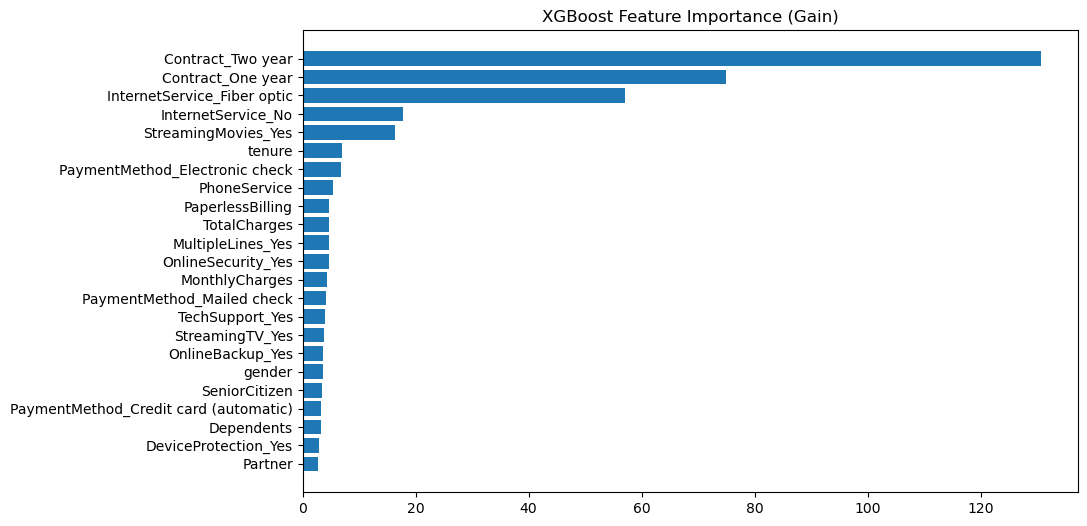

In [86]:
import xgboost as xgb
import pandas as pd
import matplotlib.pyplot as plt

booster = xgb_model.get_booster()
score = booster.get_score(importance_type="gain")

fi = pd.DataFrame(score.items(), columns=["feature", "gain"])
fi = fi.sort_values("gain", ascending=False)

print(fi.head(15))

plt.figure(figsize=(10, 6))
plt.barh(fi["feature"].head(30)[::-1], fi["gain"].head(30)[::-1])
plt.title("XGBoost Feature Importance (Gain)")
plt.show()

In [87]:
%pip install shap


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: /Users/yassinmarwan/anaconda3/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


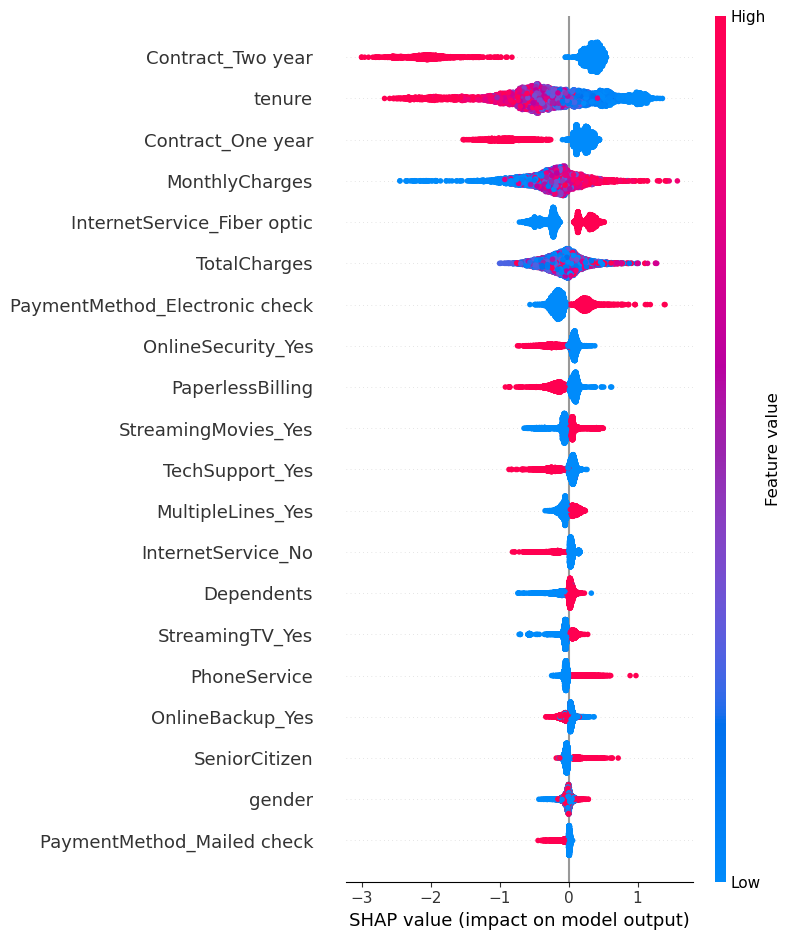

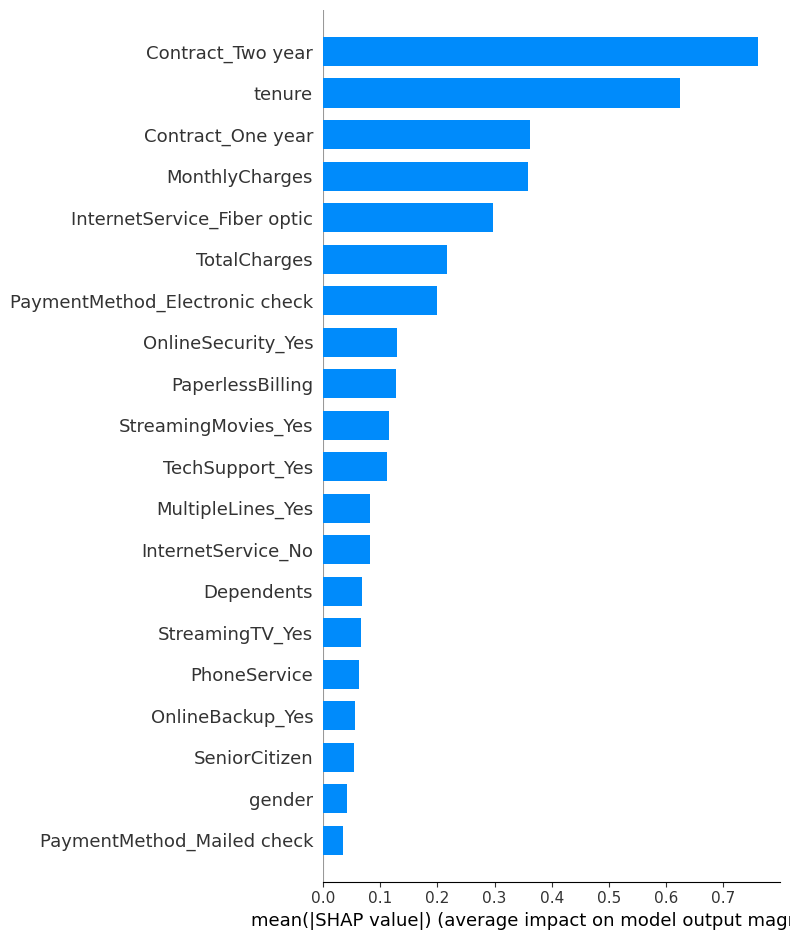

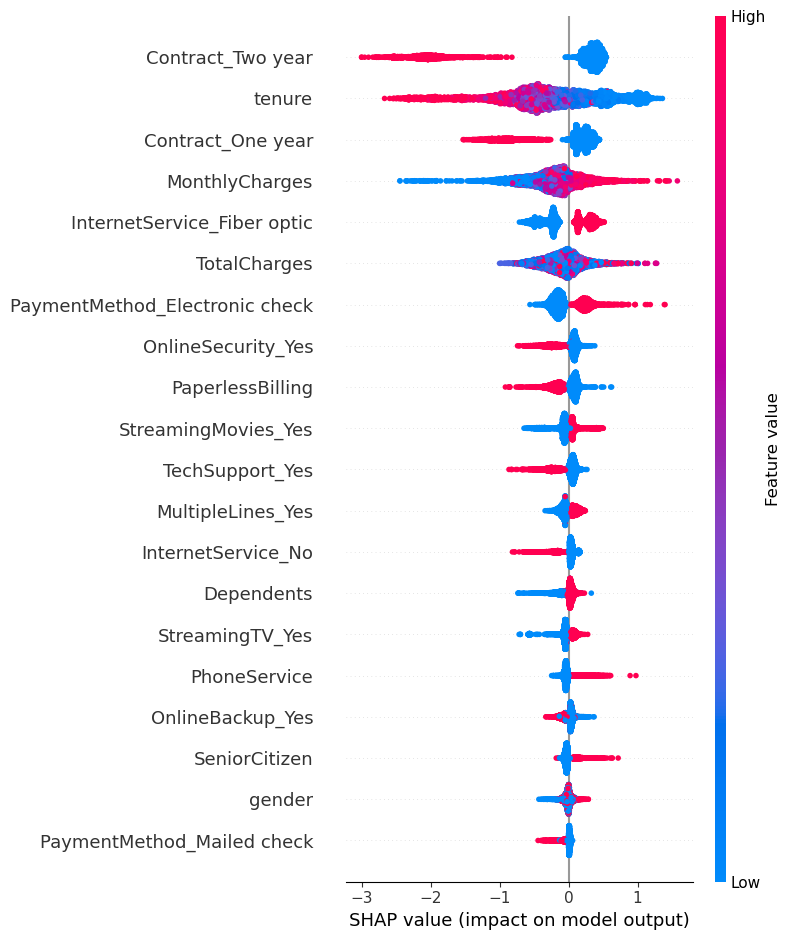

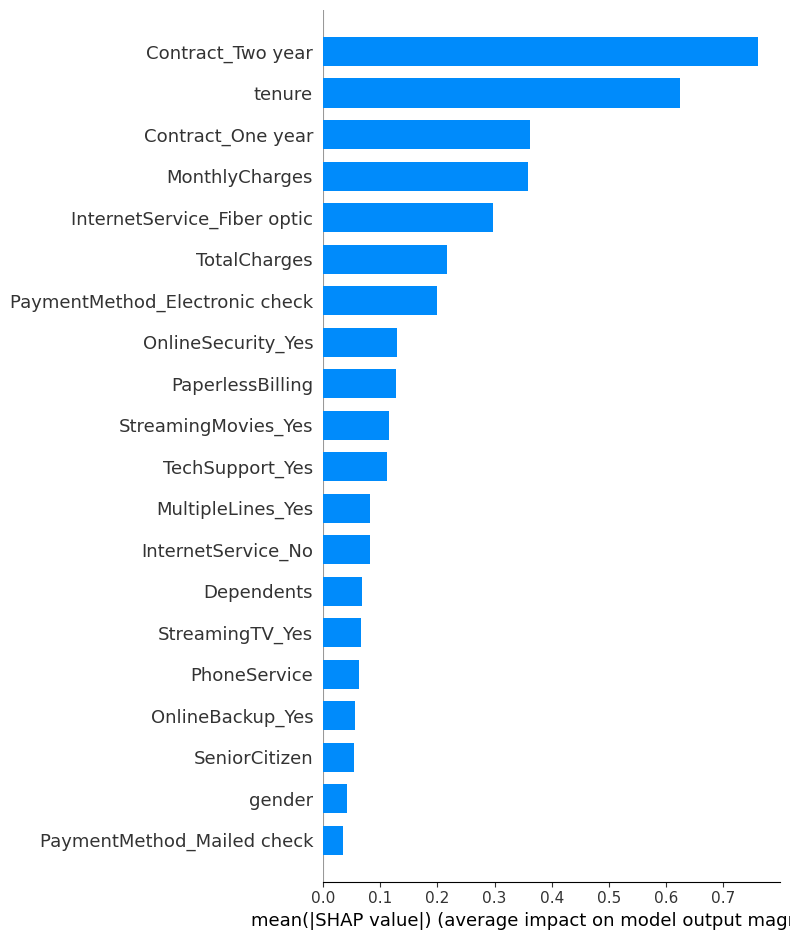

In [88]:
import shap

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_train)

shap.summary_plot(shap_values, X_train)
shap.summary_plot(shap_values, X_train, plot_type="bar")
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_train)

shap.summary_plot(shap_values, X_train)
shap.summary_plot(shap_values, X_train, plot_type="bar")


### Shap analysis
SHAP analysis confirms that long-term contract commitments and extended tenure are the primary protective factors preventing customer churn. Conversely, high monthly charges, Fiber Optic internet subscriptions, and manual electronic check payments drive customer churn risk.

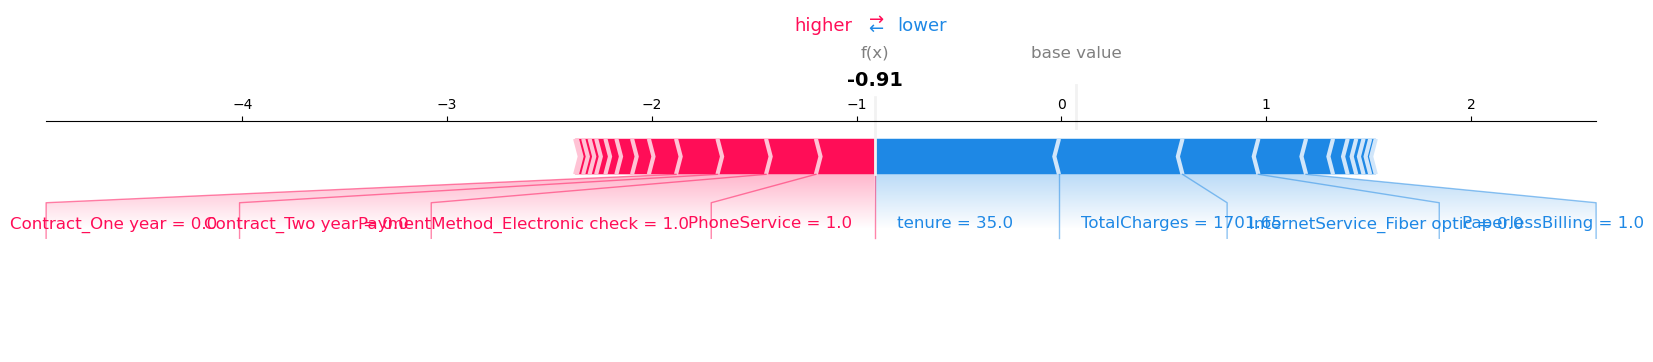

In [89]:
i = 0  # choose a row
shap.force_plot(explainer.expected_value, shap_values[i], X_train.iloc[i], matplotlib=True)

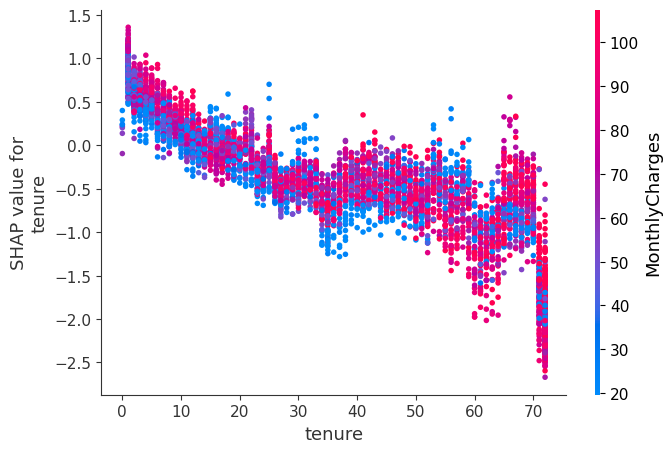

In [90]:
shap.dependence_plot("tenure", shap_values, X_train)

### Dependence plot analysis
The SHAP dependence plot reveals a non-linear relationship between tenure and monthly charges. While new customers (0–10 months) face inherently elevated churn risk across all spending levels, high monthly charges significantly amplify onboarding churn risk. Conversely, among long-tenured customers ($60+$ months), high monthly charges correlate with the strongest retention effect, indicating deep service adoption among loyal users.

# Final Analysis

## Top Churn Drivers (Ranked by Predictive Power & Risk Impact)
### Short Customer Tenure (0–15 Months)
1. statistical impact: Most dominant linear predictor in Linear Regression model
2. Early intervention is critical in the first 15 month of the tenure to build the customer loyalty

### Abscense of contract structure
1. Statistical Impact: XGBoost gain analysis identified contract type as the single most critical decision split (130.59 Gain for 2-year; 74.85 Gain for 1-year).
2. The absence of fixed-term contracts (Contract_One year = 0, Contract_Two year = 0) acts as the primary force pushing customer risk into positive churn territory.

### High Monthly Charges & Fiber Optic Service
1. stastical impact Fiber Optic subscription is the strongest discrete risk factor in logistic regression (B = +0.7788) and XGBoost gain (57.86 Gain). 
2. High billing amounts interact synergistically with short tenure. New customers who experience billing shock or performance issues with premium Fiber Optic plans show the highest rate of immediate cancellation.


## Top Protective Factors (Ranked by Retention Strength)
### High Customer Tenure (20+ Months)
1. statistical impact: The SHAP dependence curve demonstrates a distinct inflection point at 15–20 months. Beyond 20 months, tenure values transition into strong negative SHAP territory (SHAP = -0.5 to -2.5)
2. Customers who survive past the 20-month mark exhibit strong brand loyalty and deep service integration, rendering them far less sensitive to minor price fluctuations

### Long-Term Contracts (Two-Year & One-Year)
1. Statistical Impact: Two-year contracts provide double the protective effect of one-year agreements in logistic regression (B = -0.5890$ vs. -0.2865). Both features show deep negative SHAP values. 
2. Multi-year agreements legally and financially lock in retention, isolating customers from competitor acquisition offers.

### Value-Added Service Bundling
1. Statistial impact: Enrolling in OnlineSecurity B = -0.1234 and TechSupport (B = -0.1002) consistently yields negative SHAP values across models.  
2. Utility add-ons increase product stickiness and overall satisfaction, reducing churn compared to standalone connectivity plans.


## Business takeaways
1. High-Risk Onboarding Focus: Early-stage customers (0–12 months) enrolled in expensive Fiber Optic plans on month-to-month billing represent the highest-risk segment requiring immediate proactive outreach.  
2. Contract Migration Strategy: Transitioning month-to-month customers onto 1- or 2-year agreements is the single most effective leverage point for lowering overall churn rates.  
3. Automated Payment Incentives: Providing one-time billing credits to switch users from Electronic Checks to automated payments removes recurring decision points that trigger cancellations.   
4. Targeted Value-Added Bundled Offers: Offering TechSupport and OnlineSecurity during the critical first 90 days increases product stickiness and accelerates customer transition into the safe, long-tenure threshold. 

# EXPORT TO STREAMLIT

In [16]:
preprocessed = preprocessing(df)

import joblib

feature_columns = preprocessed.columns.tolist()

joblib.dump(
    feature_columns,
    "models/feature_columns.pkl"
)

['models/feature_columns.pkl']

In [15]:
import os

# Create the models directory if it doesn't exist
os.makedirs("models", exist_ok=True)

In [17]:
features = joblib.load("models/feature_columns.pkl")
print(features)

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [8]:
df.to_csv("data/raw_customer_data.csv", index=False)